# Scaling analysis
This notebook reads the CSV outputs from the three folders (thread_scaling, strong_scaling, weak_scale) and plots time, speedup and efficiency for each study.
It tries to be robust to slightly different column names (e.g. `Mean_total_time`).

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os, re
from IPython.display import display

plt.style.use('seaborn-v0_8')

# helper to find a sensible time column in a dataframe
def find_time_column(df):
    candidates = ['Mean_total_time', 'Total_time', 'total_time', 'mean_total_time', 'time']
    for c in candidates:
        if c in df.columns:
            return c
    # fallback: numeric column with largest mean
    numeric = df.select_dtypes('number').columns.tolist()
    if not numeric:
        raise ValueError('no numeric columns found to use as time')
    return max(numeric, key=lambda col: df[col].mean())

def safe_read_csv(path):
    df = pd.read_csv(path)
    # strip whitespace from column names
    df.columns = df.columns.str.strip()
    return df

from pathlib import Path
# Locate data root robustly: handle running the notebook from repo root or from this folder
def locate_root():
    p = Path.cwd()
    # if we're already inside the folder, return cwd
    if p.name == 'border-checkifarrived-inner':
        return str(p)
    # walk up a few levels trying to find output/border-checkifarrived-inner
    for _ in range(6):
        candidate = p / 'output' / 'border-checkifarrived-inner'
        if candidate.exists():
            return str(candidate.resolve())
        p = p.parent
    # try relative path from current working dir
    if Path('output/border-checkifarrived-inner').exists():
        return str(Path('output/border-checkifarrived-inner').resolve())
    raise FileNotFoundError('could not locate output/border-checkifarrived-inner; cwd=' + str(Path.cwd()))

root = locate_root()
print('Using data root:', root)
thread_dir = os.path.join(root, 'thread_scaling')
strong_dir = os.path.join(root, 'strong_scaling')
weak_dir = os.path.join(root, 'weak_scale')
print('thread_dir exists=', os.path.exists(thread_dir), 'strong_dir exists=', os.path.exists(strong_dir), 'weak_dir exists=', os.path.exists(weak_dir))

Using data root: /home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner
thread_dir exists= True strong_dir exists= True weak_dir exists= True


In [15]:
# THREAD SCALING: read CSVs and build DataFrame with Threads and Time
thread_files = sorted(glob.glob(os.path.join(thread_dir, 'thread_scaling_*_threads.csv')))
print(thread_files)
thread_rows = []
for p in thread_files:
    fn = os.path.basename(p)
    m = re.search(r'thread_scaling_(\d+)_threads\.csv', fn)
    if not m:
        continue
    threads = int(m.group(1))
    df = safe_read_csv(p)
    tcol = find_time_column(df)
    time = float(df[tcol].iloc[0])
    thread_rows.append((threads, time, p))

if thread_rows:
    threads_df = pd.DataFrame(thread_rows, columns=['Threads','Time','path']).sort_values('Threads').reset_index(drop=True)
    threads_df['Speedup'] = threads_df['Time'].iloc[0] / threads_df['Time']
    threads_df['Efficiency'] = threads_df['Speedup'] / threads_df['Threads']
else:
    threads_df = pd.DataFrame(columns=['Threads','Time','path','Speedup','Efficiency'])
threads_df

['/home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner/thread_scaling/thread_scaling_112_threads.csv', '/home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner/thread_scaling/thread_scaling_16_threads.csv', '/home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner/thread_scaling/thread_scaling_1_threads.csv', '/home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner/thread_scaling/thread_scaling_2_threads.csv', '/home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner/thread_scaling/thread_scaling_32_threads.csv', '/home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner/thread_scaling/thread_scaling_4_threads.csv', '/home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner/thread_scaling/thread_scaling_56_threads.csv', '/home/alessiovalle/GitRepos/esame-hpc/output/border-checkifarrived-inner/thread_scaling/thread_scaling_84_threads.csv', '/home/alessiovalle/GitRepos/esam

,Threads,Time,path,Speedup,Efficiency
0,1,324.759144,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.000000,1.000000
1,2,180.452127,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.799697,0.899848
2,4,115.826694,/home/alessiovalle/GitRepos/esame-hpc/output/b...,2.803837,0.700959
3,8,90.939652,/home/alessiovalle/GitRepos/esame-hpc/output/b...,3.571150,0.446394
4,16,70.795539,/home/alessiovalle/GitRepos/esame-hpc/output/b...,4.587283,0.286705
5,32,36.828247,/home/alessiovalle/GitRepos/esame-hpc/output/b...,8.818208,0.275569
6,56,21.112969,/home/alessiovalle/GitRepos/esame-hpc/output/b...,15.381974,0.274678
7,84,16.049028,/home/alessiovalle/GitRepos/esame-hpc/output/b...,20.235440,0.240898
8,112,12.702944,/home/alessiovalle/GitRepos/esame-hpc/output/b...,25.565660,0.228265


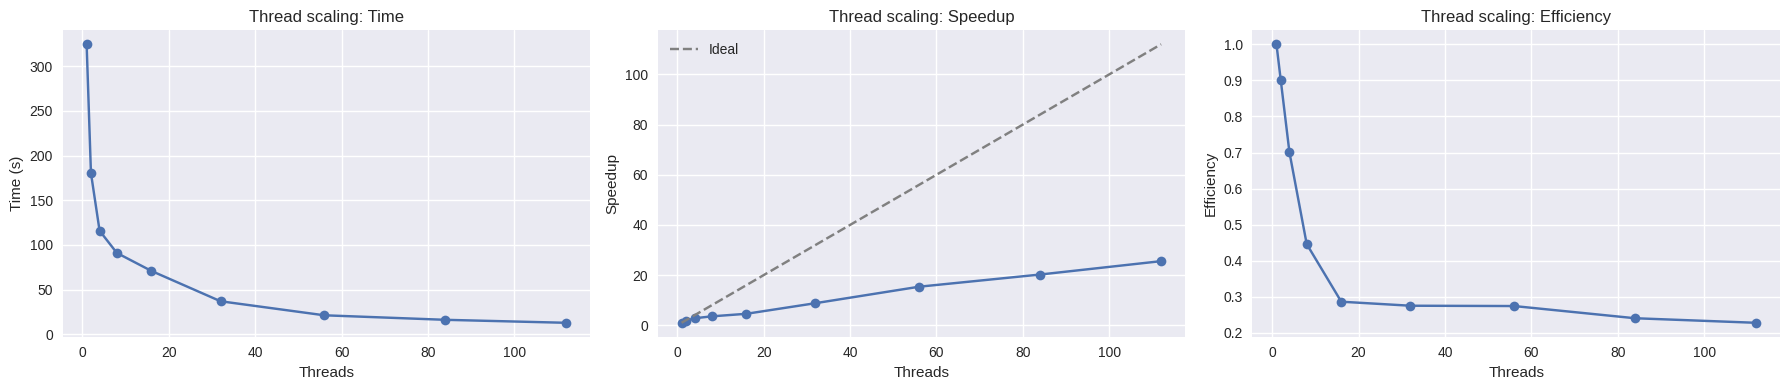

In [16]:
# Plot thread scaling: time, speedup, efficiency
fig, axes = plt.subplots(1,3, figsize=(18,4))
axes[0].plot(threads_df['Threads'], threads_df['Time'], marker='o')
axes[0].set_xlabel('Threads')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Thread scaling: Time')

axes[1].plot(threads_df['Threads'], threads_df['Speedup'], marker='o')
axes[1].plot(threads_df['Threads'], threads_df['Threads'], color='gray', ls='--', label='Ideal')
axes[1].set_xlabel('Threads')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Thread scaling: Speedup')
axes[1].legend()

axes[2].plot(threads_df['Threads'], threads_df['Efficiency'], marker='o')
axes[2].set_xlabel('Threads')
axes[2].set_ylabel('Efficiency')
axes[2].set_title('Thread scaling: Efficiency')
plt.tight_layout()
plt.show()

In [17]:
# STRONG SCALING: read CSVs and build DataFrame with Nodes and Time
strong_files = sorted(glob.glob(os.path.join(strong_dir, 'strong_scaling_*n_*t.csv')))
strong_rows = []
for p in strong_files:
    fn = os.path.basename(p)
    m = re.search(r'strong_scaling_(\d+)n_(\d+)t\.csv', fn)
    if not m:
        continue
    nodes = int(m.group(1))
    tasks = int(m.group(2))
    df = safe_read_csv(p)
    tcol = find_time_column(df)
    time = float(df[tcol].iloc[0])
    strong_rows.append((nodes, tasks, time, p))

strong_df = pd.DataFrame(strong_rows, columns=['Nodes','Tasks','Time','path']).sort_values('Nodes').reset_index(drop=True)
# Speedup relative to 1-node baseline (smallest Nodes value)
one_node_time = strong_df.loc[strong_df['Nodes']==strong_df['Nodes'].min(),'Time'].iloc[0]
strong_df['Speedup'] = one_node_time / strong_df['Time']
strong_df['Efficiency'] = strong_df['Speedup'] / strong_df['Nodes']
strong_df

,Nodes,Tasks,Time,path,Speedup,Efficiency
0,1,8,10.763840,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.000000,1.000000
1,2,16,5.440082,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.978617,0.989309
2,4,32,2.524071,/home/alessiovalle/GitRepos/esame-hpc/output/b...,4.264476,1.066119
3,8,64,1.070100,/home/alessiovalle/GitRepos/esame-hpc/output/b...,10.058723,1.257340
4,16,128,0.399691,/home/alessiovalle/GitRepos/esame-hpc/output/b...,26.930404,1.683150


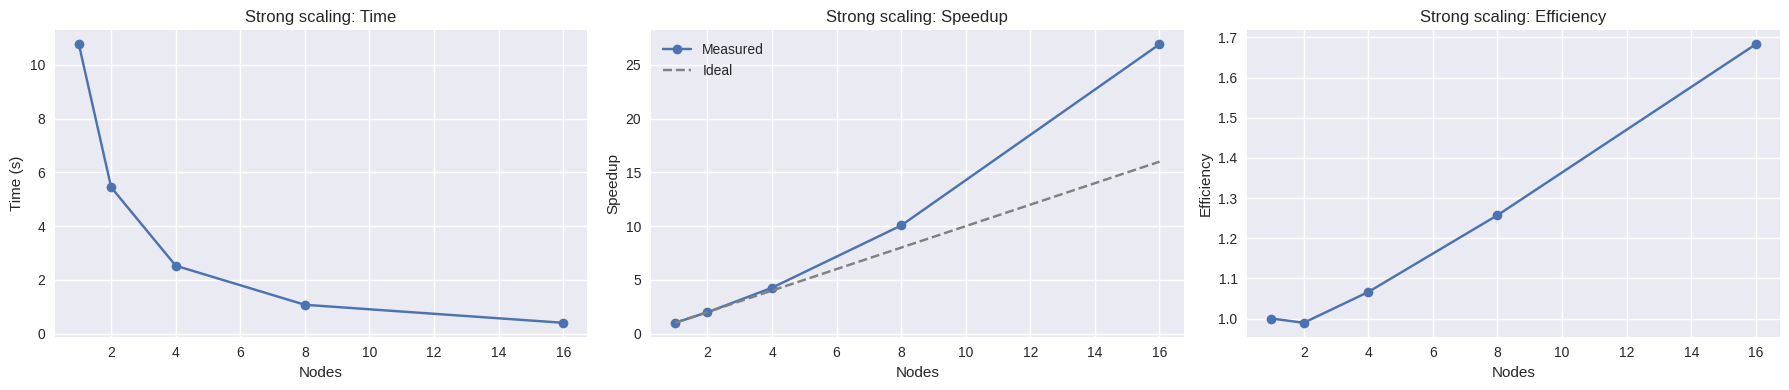

In [18]:
# Plot strong scaling
fig, axes = plt.subplots(1,3, figsize=(18,4))
axes[0].plot(strong_df['Nodes'], strong_df['Time'], marker='o')
axes[0].set_xlabel('Nodes')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Strong scaling: Time')

axes[1].plot(strong_df['Nodes'], strong_df['Speedup'], marker='o', label='Measured')
axes[1].plot(strong_df['Nodes'], strong_df['Nodes'], color='gray', ls='--', label='Ideal')
axes[1].set_xlabel('Nodes')
axes[1].set_ylabel('Speedup')
axes[1].set_title('Strong scaling: Speedup')
axes[1].legend()

axes[2].plot(strong_df['Nodes'], strong_df['Efficiency'], marker='o')
axes[2].set_xlabel('Nodes')
axes[2].set_ylabel('Efficiency')
axes[2].set_title('Strong scaling: Efficiency')
plt.tight_layout()
plt.show()

In [19]:
# WEAK SCALING: read CSVs and build DataFrame with Nodes and Time
weak_files = sorted(glob.glob(os.path.join(weak_dir, 'weak_scale_*n_*t.csv')))
weak_rows = []
for p in weak_files:
    fn = os.path.basename(p)
    m = re.search(r'weak_scale_(\d+)n_(\d+)t\.csv', fn)
    if not m:
        continue
    nodes = int(m.group(1))
    tasks = int(m.group(2))
    df = safe_read_csv(p)
    tcol = find_time_column(df)
    time = float(df[tcol].iloc[0])
    weak_rows.append((nodes, tasks, time, p))

weak_df = pd.DataFrame(weak_rows, columns=['Nodes','Tasks','Time','path']).sort_values('Nodes').reset_index(drop=True)
# For weak scaling, compute relative runtime to 1-node baseline and efficiency (lower is worse)
base_time = weak_df.loc[weak_df['Nodes']==weak_df['Nodes'].min(),'Time'].iloc[0]
weak_df['Relative'] = weak_df['Time'] / base_time
weak_df['Efficiency'] = 1.0 / weak_df['Relative']
weak_df

,Nodes,Tasks,Time,path,Relative,Efficiency
0,1,8,0.225359,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.000000,1.000000
1,2,16,0.297684,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.320932,0.757041
2,4,32,0.275590,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.222893,0.817733
3,8,64,0.225775,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.001846,0.998157
4,16,128,0.242632,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.076647,0.928810


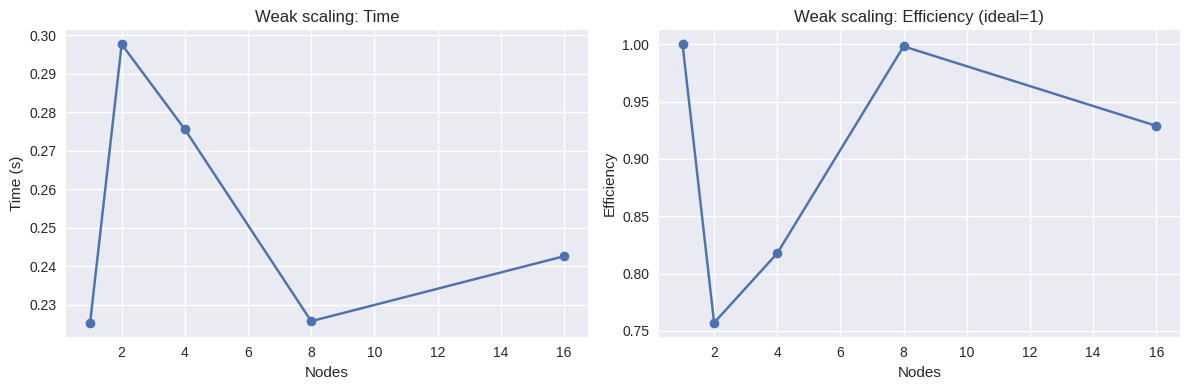

In [20]:
# Plot weak scaling (efficiency and relative time)
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(weak_df['Nodes'], weak_df['Time'], marker='o')
axes[0].set_xlabel('Nodes')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Weak scaling: Time')

axes[1].plot(weak_df['Nodes'], weak_df['Efficiency'], marker='o')
axes[1].set_xlabel('Nodes')
axes[1].set_ylabel('Efficiency')
axes[1].set_title('Weak scaling: Efficiency (ideal=1)')
plt.tight_layout()
plt.show()

In [21]:
# Print summary tables for quick inspection
print('=== Threads study ===')
display(threads_df)
print('\n=== Strong scaling study ===')
display(strong_df)
print('\n=== Weak scaling study ===')
display(weak_df)

=== Threads study ===


,Threads,Time,path,Speedup,Efficiency
0,1,324.759144,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.000000,1.000000
1,2,180.452127,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.799697,0.899848
2,4,115.826694,/home/alessiovalle/GitRepos/esame-hpc/output/b...,2.803837,0.700959
3,8,90.939652,/home/alessiovalle/GitRepos/esame-hpc/output/b...,3.571150,0.446394
4,16,70.795539,/home/alessiovalle/GitRepos/esame-hpc/output/b...,4.587283,0.286705
5,32,36.828247,/home/alessiovalle/GitRepos/esame-hpc/output/b...,8.818208,0.275569
6,56,21.112969,/home/alessiovalle/GitRepos/esame-hpc/output/b...,15.381974,0.274678
7,84,16.049028,/home/alessiovalle/GitRepos/esame-hpc/output/b...,20.235440,0.240898
8,112,12.702944,/home/alessiovalle/GitRepos/esame-hpc/output/b...,25.565660,0.228265



=== Strong scaling study ===


,Nodes,Tasks,Time,path,Speedup,Efficiency
0,1,8,10.763840,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.000000,1.000000
1,2,16,5.440082,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.978617,0.989309
2,4,32,2.524071,/home/alessiovalle/GitRepos/esame-hpc/output/b...,4.264476,1.066119
3,8,64,1.070100,/home/alessiovalle/GitRepos/esame-hpc/output/b...,10.058723,1.257340
4,16,128,0.399691,/home/alessiovalle/GitRepos/esame-hpc/output/b...,26.930404,1.683150



=== Weak scaling study ===


,Nodes,Tasks,Time,path,Relative,Efficiency
0,1,8,0.225359,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.000000,1.000000
1,2,16,0.297684,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.320932,0.757041
2,4,32,0.275590,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.222893,0.817733
3,8,64,0.225775,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.001846,0.998157
4,16,128,0.242632,/home/alessiovalle/GitRepos/esame-hpc/output/b...,1.076647,0.928810
